## Human in the Loop Workflow

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, AIMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langgraph.types import interrupt, Command

In [2]:
load_dotenv()
model = ChatGroq(model="llama-3.3-70b-versatile")

In [3]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type":"approval",
        "reason": "Model is about to answer a user question",
        "question": state["messages"][-1].content,
        "instructions": "Approve this queestion? Yes/No"
    })

    if decision["approved"] =="no":
        return {"messages": [AIMessage(content="Question not approved!")]}
    else:
        response = model.invoke(state["messages"])
        return {"messages": [response]}

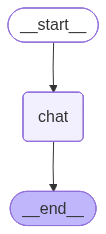

In [5]:
graph = StateGraph(ChatState)

graph.add_node("chat",chat_node)

graph.add_edge(START, "chat")
graph.add_edge("chat",END)

checkpointer = InMemorySaver()

app = graph.compile(checkpointer=checkpointer)
app

In [15]:
config = {"configurable":{"thread_id":"1234"}}

intial_input = {
    "messages": [
        ("user", "What is love?")
    ]
}

result = app.invoke(intial_input,config=config)


In [16]:
result

{'messages': [HumanMessage(content='What is love?', additional_kwargs={}, response_metadata={}, id='24e4bc01-4a8a-4295-a3b5-e3fdc64e4bf3'),
  AIMessage(content="Love is a complex and multifaceted concept that has been debated and explored by philosophers, psychologists, scientists, and many others throughout history. While there's no one definitive answer, here's a comprehensive overview:\n\n**Definitions:**\n\n1. **Emotional connection:** Love is often described as a strong emotional bond between two people, characterized by feelings of affection, attachment, and intimacy.\n2. **Commitment:** Love can also be seen as a commitment to care for, support, and prioritize the well-being of another person, often accompanied by a sense of responsibility and loyalty.\n3. **Chemistry:** Some people describe love as a chemical or biological response, triggered by the release of neurotransmitters and hormones such as oxytocin, dopamine, and serotonin, which can create feelings of pleasure, excite

In [17]:
interrupt_msg = result['__interrupt__'][0].value
interrupt_msg

{'type': 'approval',
 'reason': 'Model is about to answer a user question',
 'question': 'What is love?',
 'instructions': 'Approve this queestion? Yes/No'}

In [18]:
user_input = input(f"\nBackend Message - {interrupt_msg} \n Approve this question? (yes/no): ")

In [19]:
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config
)

In [20]:
final_result

{'messages': [HumanMessage(content='What is love?', additional_kwargs={}, response_metadata={}, id='24e4bc01-4a8a-4295-a3b5-e3fdc64e4bf3'),
  AIMessage(content="Love is a complex and multifaceted concept that has been debated and explored by philosophers, psychologists, scientists, and many others throughout history. While there's no one definitive answer, here's a comprehensive overview:\n\n**Definitions:**\n\n1. **Emotional connection:** Love is often described as a strong emotional bond between two people, characterized by feelings of affection, attachment, and intimacy.\n2. **Commitment:** Love can also be seen as a commitment to care for, support, and prioritize the well-being of another person, often accompanied by a sense of responsibility and loyalty.\n3. **Chemistry:** Some people describe love as a chemical or biological response, triggered by the release of neurotransmitters and hormones such as oxytocin, dopamine, and serotonin, which can create feelings of pleasure, excite